#Info 2950 Project- Phase II 
Members: 
Marianna Ruggiero
mir46@cornell.edu

Joyce Han
jh2969@cornell.edu

Fiona Chandler
fcc42@cornell.edu

Friana Engineer
fe63@cornell.edu

Question: Is the percentage of US jobs that require AI skills associated with the percentage of Cornell courses that teach about AI over time? Can we predict future Cornell AI class numbers with the percentage of US jobs that require AI skills?

##Data Description


###Cornell API: https://classes.cornell.edu/content/SU17/api-details
The Cornell Roster API is an API that enables us to access Class Roster Data from the years 2016 to 2025.
We obtained the following attributes from the raw data:
* term: the semester in which the course was offered, such as FA21 or SP25.
* crseId: the Cornell course identifier.
* subject: the academic subject or department associated with the course.
* catalogNbr: the course catalog number.
* title: the course's title.
* description: the course description provided by Cornell.
* college: the Cornell academic group associated with the course.
* career: the academic career associated with the course.


We also created the following attributes:
* AI_narrow: indicates whether the course title or description contains "artificial intelligence," "machine learning," or the term "AI."
* AI_broad: indicates whether the course title or description contains one of the terms in our broader AI definition.


For our primary analysis we use AI_broad because it captures a wider classification of what it means to have a course that focuses on teaching students AI skills. This data was then grouped by semester and aggregated to understand the total number of courses per semester, per subject. As well as the number of courses from all courses per semester, that teach about AI. In addition to that we obtained the percentage of courses that teach AI.


The dataset was not originally created by Cornell, instead we used the Cornell class roster API to create this dataset to answer our research question.


Some limitations to the dataset is that if there is any missing data from the Cornell Class Roster we would be unable to obtain this missing data. Additionally, the fact that we only have the Cornell roster limits our analysis to only Cornell classes and how those are influenced by the number of AI jobs on the market. Another limitation is that we are determining what it means for a class to be AI focused from the course description. The course description is a very limited version of what the course contents actually are and therefore this is vulnerable to errors since we can only tell so much from the course description. This means that we might be underestimating or overestimating the number of courses that teach AI skills. Lastly, another limitation is the relatively short period of time for which we have course descriptions. If we had a dataset that encompassed more semesters this would allow us to do a more in depth analysis.


The raw JSON responses downloaded through the API are included in our project repository so that the dataset can be reproduced. Our processed dataset can be generated from these raw files using the Python code described below. The JSON files can also be obtained directly from using the Cornell Roster API.


### set up data

In [1]:
import json, re, time, pathlib
import requests
import pandas as pd

BASE = "https://classes.cornell.edu/api/2.0"
TERMS = ["FA14",
         "SP15", "FA15", 
         "SP16", "FA16", 
         "SP17", "FA17", 
         "SP18", "FA18",
         "SP19", "FA19", 
         "SP20", "FA20", 
         "SP21", "FA21", 
         "SP22", "FA22",
         "SP23", "FA23", 
         "SP24", "FA24", 
         "SP25", "FA25", 
         "SP26"]
#TERMS = ["FA21"]
SLEEP = 0.25
RAW = pathlib.Path("raw")
RAW.mkdir(exist_ok=True)

### now we have successful response. so we collect data

In [2]:
def get_subjects(term):
    r = requests.get(f"{BASE}/config/subjects.json", params={"roster": term})
    r.raise_for_status()
    return r.json()["data"]["subjects"]

def fetch(term, subject):
    path = RAW / f"{term}_{subject}.json"
    if path.exists():
        return
    r = requests.get(f"{BASE}/search/classes.json",
                     params={"roster": term, "subject": subject})
    r.raise_for_status()
    path.write_text(json.dumps(r.json()))
    time.sleep(0.5)

failed = []
for term in TERMS:
    for s in get_subjects(term):
        code = s["value"]  # if this errors, print(s) and use the field that holds the subject code
        try:
            fetch(term, code)
        except Exception as e:
            failed.append((term, code, str(e)))
print("failed requests:", len(failed))

failed requests: 1


### lets flatten!

In [9]:
rows = []
for path in sorted(RAW.glob("*.json")):
    term = path.stem.split("_", 1)[0]
    classes = json.loads(path.read_text()).get("data", {}).get("classes", [])
    for c in classes:
        rows.append({
            "term": term,
            "crseId": c.get("crseId"),
            "subject": c.get("subject"),
            "catalogNbr": c.get("catalogNbr"),
            "title": c.get("titleLong") or "",
            "description": c.get("description") or "",
            "college": c.get("acadGroup"),
            "career": c.get("acadCareer"),
        })
df = pd.DataFrame(rows)
df["term"] = pd.Categorical(df["term"], categories=TERMS, ordered=True)
print(df.groupby("term", observed=True).size())

term
FA14    4000
SP15    4088
FA15    4074
SP16    4198
FA16    4050
SP17    4228
FA17    4129
SP18    4262
FA18    4186
SP19    4272
FA19    4187
SP20    4233
FA20    4088
SP21    4231
FA21    4298
SP22    4544
FA22    4360
SP23    4659
FA23    4564
SP24    4524
FA24    4549
SP25    4697
FA25    4459
SP26    4568
dtype: int64


### yay now we flag for AI

In [4]:
text = df["title"] + " " + df["description"]

narrow = re.compile(r"artificial intelligence|machine learning", re.I)
broad = re.compile(r"artificial intelligence|machine learning|deep learning|neural network|"
                   r"large language model|natural language processing|reinforcement learning|"
                   r"computer vision", re.I)
ai_word = re.compile(r"\bAI\b")

df["ai_narrow"] = text.apply(lambda t: bool(narrow.search(t) or ai_word.search(t)))
df["ai_broad"] = text.apply(lambda t: bool(broad.search(t) or ai_word.search(t)))

flagged = df[df["ai_narrow"]]
flagged[["term", "subject", "catalogNbr", "title"]].sample(min(8, len(flagged)), random_state=0)

,term,subject,catalogNbr,title
61560,SP17,INFO,4120,Ubiquitous Computing
45152,FA24,NBA,5600,Demystifying Big Data and FinTech
49831,FA25,ORIE,5256,Special Topics in Financial Engineering V
99451,SP26,ASIAN,4443,Work and Labor in China
90679,SP24,CHEME,4800,Principles of Computational Thinking for Engin...
86359,SP23,CS,5780,Introduction to Machine Learning
1195,FA14,CS,5785,Modern Analytics
34315,FA22,CS,5306,Crowdsourcing and Human Computation


### dedupe and compare!

In [5]:
by_id = df.drop_duplicates(["term", "crseId"])
by_text = df.drop_duplicates(["term", "title", "description"])

rules = {"no dedupe": df, "crseId (main)": by_id, "title+description": by_text}
print(pd.DataFrame({
    name: {"courses": len(d),
           "AI share (narrow)": round(d["ai_narrow"].mean(), 3),
           "AI share (broad)": round(d["ai_broad"].mean(), 3)}
    for name, d in rules.items()
}).T)

                    courses  AI share (narrow)  AI share (broad)
no dedupe          103448.0              0.013             0.016
crseId (main)       84725.0              0.013             0.016
title+description   78667.0              0.012             0.015


### by term

      courses  ai_narrow  ai_broad
term                              
FA14     3250      0.004     0.005
SP15     3364      0.004     0.007
FA15     3355      0.004     0.006
SP16     3466      0.005     0.007
FA16     3303      0.004     0.007
SP17     3487      0.007     0.008
FA17     3404      0.006     0.009
SP18     3519      0.007     0.008
FA18     3459      0.009     0.011
SP19     3514      0.010     0.011
FA19     3466      0.008     0.011
SP20     3451      0.012     0.014
FA20     3318      0.011     0.014
SP21     3421      0.015     0.018
FA21     3520      0.012     0.016
SP22     3705      0.014     0.015
FA22     3640      0.012     0.015
SP23     3794      0.020     0.022
FA23     3723      0.017     0.021
SP24     3735      0.021     0.025
FA24     3692      0.020     0.025
SP25     3808      0.027     0.030
FA25     3623      0.029     0.033
SP26     3708      0.038     0.041


<Axes: title={'center': 'Share of Cornell courses mentioning AI, by term'}, xlabel='term', ylabel='share of courses mentioning AI'>

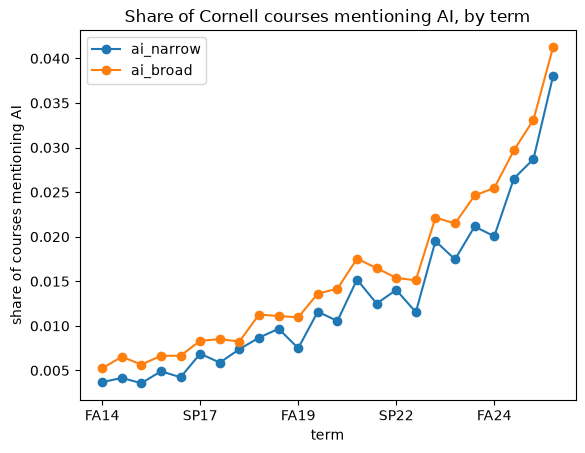

In [6]:
by_term = by_id.groupby("term", observed=True).agg(
    courses=("crseId", "size"),
    ai_narrow=("ai_narrow", "mean"),
    ai_broad=("ai_broad", "mean"),
)
print(by_term.round(3))
by_term[["ai_narrow", "ai_broad"]].plot(
    marker="o", ylabel="share of courses mentioning AI",
    title="Share of Cornell courses mentioning AI, by term")

### by subject

In [7]:
by_subject = (by_id.groupby("subject")
              .agg(courses=("crseId", "size"),
                   ai_courses=("ai_broad", "sum"),
                   share=("ai_broad", "mean"))
              .query("courses >= 20")
              .sort_values("share", ascending=False))
print(by_subject.head(15).round(3))

         courses  ai_courses  share
subject                            
CS          2084         501  0.240
BIOCB         55          12  0.218
INFO         878         116  0.132
STSCI        502          42  0.084
SYSEN        388          29  0.075
ORIE        1036          71  0.069
ECE         1074          71  0.066
PLBIO        323          18  0.056
COGST        423          22  0.052
ENMGT         78           4  0.051
MGMT         137           7  0.051
ILRGL        164           8  0.049
NBAY         318          15  0.047
TECH         145           6  0.041
CHEME        803          32  0.040


### blank descs.

In [8]:
blank = by_id["description"].str.strip() == ""
print(blank.groupby(by_id["term"], observed=True).mean().round(3))

term
FA14    0.088
SP15    0.090
FA15    0.058
SP16    0.071
FA16    0.038
SP17    0.050
FA17    0.035
SP18    0.054
FA18    0.045
SP19    0.058
FA19    0.036
SP20    0.046
FA20    0.028
SP21    0.049
FA21    0.036
SP22    0.048
FA22    0.029
SP23    0.047
FA23    0.024
SP24    0.034
FA24    0.012
SP25    0.029
FA25    0.016
SP26    0.018
Name: description, dtype: float64
